In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv('./defefcts.csv')
dataset

,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,returnQty,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
0,5,60,2,55,189,27,5,30,247,25,...,4,2,47,9,27,5,17,3,191,0
1,3,10,1,1,9,7,4,1,38,7,...,0,0,0,22,4,0,4,2,69,0
2,3,10,1,1,9,7,4,0,38,7,...,0,0,0,22,4,0,4,2,69,1
3,20,59,3,63,189,24,9,4,262,12,...,0,6,6,14,45,8,41,4,222,0
4,21,58,2,61,189,24,9,0,260,12,...,0,6,6,14,45,8,41,4,222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6047,52,124,12,144,963,110,9,0,804,20,...,0,0,26,16,32,4,30,6,689,1
6048,24,27,2,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,0
6049,22,27,1,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,1
6050,3,12,2,12,28,8,0,1,67,7,...,2,0,0,2,10,0,8,2,36,0


# Описание признаков датасета

| Признак | Описание |
|---------|----------|
| `cbo` | Coupling Between Objects (связи между классами) |
| `wmc` | Weighted Methods per Class (суммарная сложность методов) |
| `dit` | Depth of Inheritance Tree (глубина наследования) |
| `rfc` | Response for a Class (количество вызываемых методов) |
| `lcom` | Lack of Cohesion of Methods (несвязанность методов) |
| `totalMethods` | Общее количество методов |
| `totalFields` | Общее количество полей |
| `nosi` | Number of Static Invocations (вызовы статических методов) |
| `loc` | Lines of Code (строк кода) |
| `returnQty` | Количество операторов `return` |
| `loopQty` | Количество циклов (`for`, `while`) |
| `comparisonsQty` | Количество сравнений (`if`, `case`) |
| `tryCatchQty` | Количество блоков `try-catch` |
| `parenthesizedExpsQty` | Количество выражений в скобках |
| `stringLiteralsQty` | Количество строковых литералов |
| `numbersQty` | Количество числовых литералов |
| `assignmentsQty` | Количество присваиваний |
| `mathOperationsQty` | Количество математических операций |
| `variablesQty` | Количество переменных |
| `maxNestedBlocks` | Максимальная вложенность блоков кода |
| `uniqueWordsQty` | Количество уникальных слов в коде |
| `defect` | Целевая переменная (1 — есть дефект, 0 — нет) |

Категориальных данных, неунитарно кодированных, нет, поэтому дополнительного кодирования производить не нужно

In [3]:
dataset.isnull().sum()

cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
returnQty               0
loopQty                 0
comparisonsQty          0
tryCatchQty             0
parenthesizedExpsQty    0
stringLiteralsQty       0
numbersQty              0
assignmentsQty          0
mathOperationsQty       0
variablesQty            0
maxNestedBlocks         0
uniqueWordsQty          0
defect                  0
dtype: int64

Пустых значений нет, значит в этом плане предобработка не требуется

In [4]:
X, y = dataset.iloc[:, :-1].values, dataset.iloc[:, -1].values
X, y

(array([[  5,  60,   2, ...,  17,   3, 191],
        [  3,  10,   1, ...,   4,   2,  69],
        [  3,  10,   1, ...,   4,   2,  69],
        ...,
        [ 22,  27,   1, ...,  24,   3, 108],
        [  3,  12,   2, ...,   8,   2,  36],
        [  5,  11,   1, ...,   7,   2,  37]], shape=(6052, 21)),
 array([0, 0, 1, ..., 1, 0, 1], shape=(6052,)))

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
X_train.shape

(4236, 21)

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)
X_train_std.shape

(4236, 21)

In [55]:
from sklearn.decomposition import PCA 
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
X_train_pca.shape

(4236, 21)

In [56]:
pca.explained_variance_ratio_

array([0.54489288, 0.09884043, 0.05769017, 0.05420303, 0.04495576,
       0.03474345, 0.02804705, 0.02687205, 0.023041  , 0.01626764,
       0.0141156 , 0.01257704, 0.010637  , 0.00888181, 0.00719938,
       0.00561606, 0.00458228, 0.00309765, 0.00210859, 0.00096158,
       0.00066955])

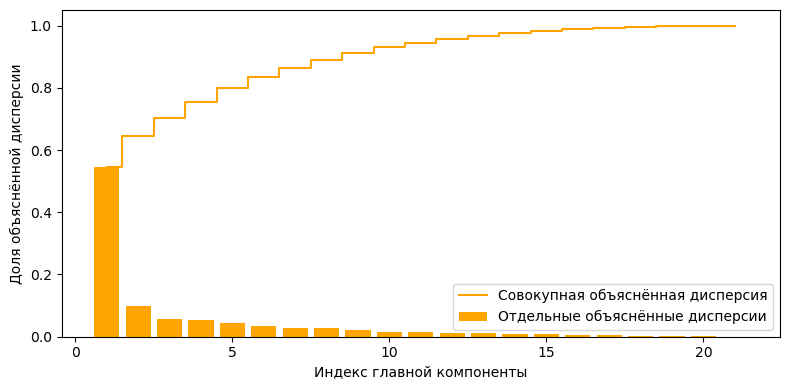

In [57]:
import matplotlib.pyplot as plt
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1), 
    pca.explained_variance_ratio_, 
    align='center', 
    label='Отдельные объяснённые дисперсии',
    color='orange'
)
plt.step(
    range(1, len(pca.explained_variance_ratio_) + 1),
    cum_var,
    where='mid',
    label='Совокупная объяснённая дисперсия',
    color='orange'
)
plt.xlabel('Индекс главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Так как первые 5 компонент описывают 80 процентов дисперсии, то рассмотрим их нагрузки

In [58]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

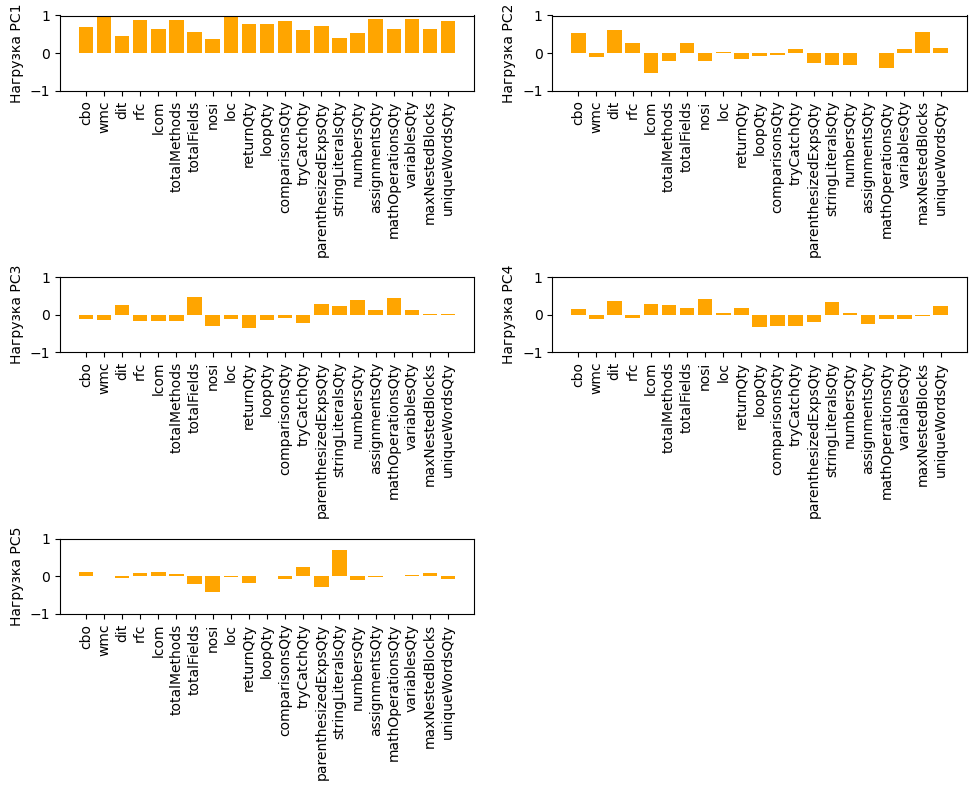

In [59]:
fig, axes = plt.subplots(3, 2, figsize=(10,8))

for i, ax in enumerate(axes.flat):
    if (i < 5):
        ax.bar(range(21), loadings[:, i], align='center', color='orange')
        ax.set_xticks(range(21))
        ax.set_xticklabels(dataset.columns[:-1], rotation=90)
        ax.set_ylabel(f'Нагрузка PC{i+1}') 
        ax.set_ylim(-1, 1) 
    else:
        ax.axis('off')
plt.ylim(-1,1)
plt.tight_layout()
plt.show()    

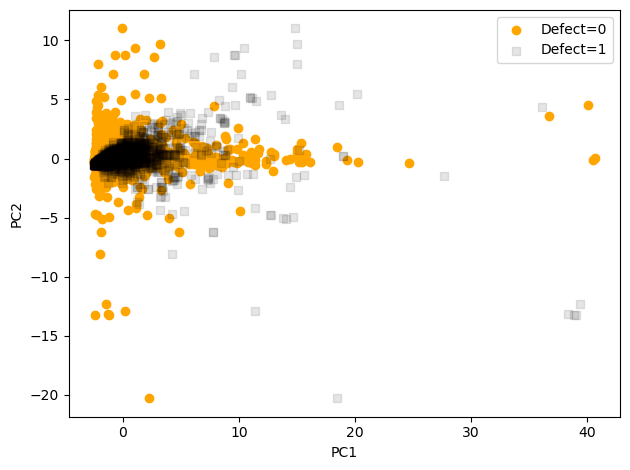

In [68]:
plt.scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==1, 1], c='orange', label='Defect=0', marker='o')
plt.scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], c='black', label='Defect=1', marker='s', alpha=0.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [53]:
from sklearn.manifold import TSNE
tsne = TSNE(init='random')
X_train_tsne = tsne.fit_transform(X_train_std)
X_train_tsne.shape

(4236, 2)

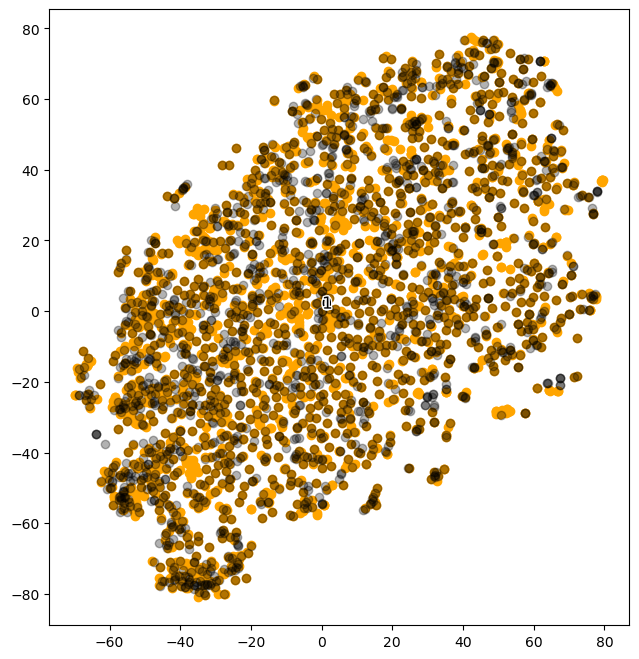

In [54]:
import matplotlib.patheffects as PathEffects

plt.figure(figsize=(8,8))
ax = plt.subplot(aspect='equal')
plt.scatter(
    X_train_tsne[y_train==0, 0], 
    X_train_tsne[y_train==0, 1], 
    color='orange'
)
xtext, ytext = np.median(X_train_tsne[y_train==0, :], axis=0)
txt = ax.text(xtext, ytext, str(0), fontsize=12)
txt.set_path_effects([
    PathEffects.Stroke(linewidth=2, foreground='white'),
    PathEffects.Normal()
])
plt.scatter(
    X_train_tsne[y_train==1, 0], 
    X_train_tsne[y_train==1, 1], 
    color='black',
    alpha=0.3
)
xtext, ytext = np.median(X_train_tsne[y_train==1, :], axis=0)
txt = ax.text(xtext, ytext, str(1), fontsize=12)
txt.set_path_effects([
    PathEffects.Stroke(linewidth=2, foreground='white'),
    PathEffects.Normal()
])
plt.show()

In [70]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA()
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_train_lda.shape

(4236, 1)

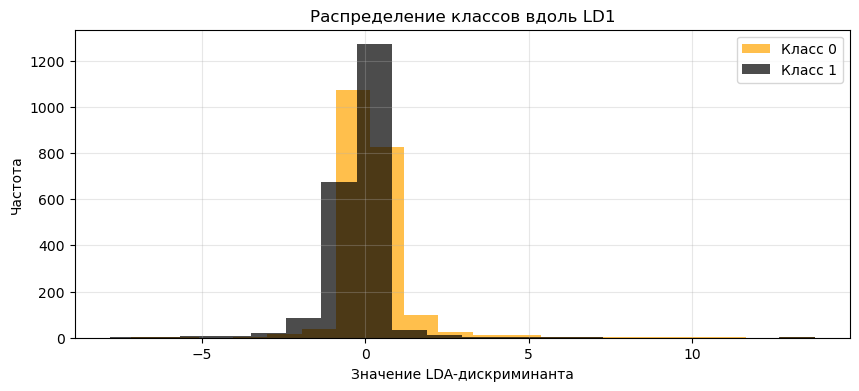

In [73]:
plt.figure(figsize=(10, 4))
plt.hist(X_train_lda[y_train==0].flatten(), bins=20, alpha=0.7, label='Класс 0', color='orange')
plt.hist(X_train_lda[y_train==1].flatten(), bins=20, alpha=0.7, label='Класс 1', color='black')
plt.xlabel('Значение LDA-дискриминанта')
plt.ylabel('Частота')
plt.title('Распределение классов вдоль LD1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [90]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=5, kernel='rbf', gamma=0.3)
X_train_kpca = kpca.fit_transform(X_train_std)
X_train_kpca.shape

(4236, 5)

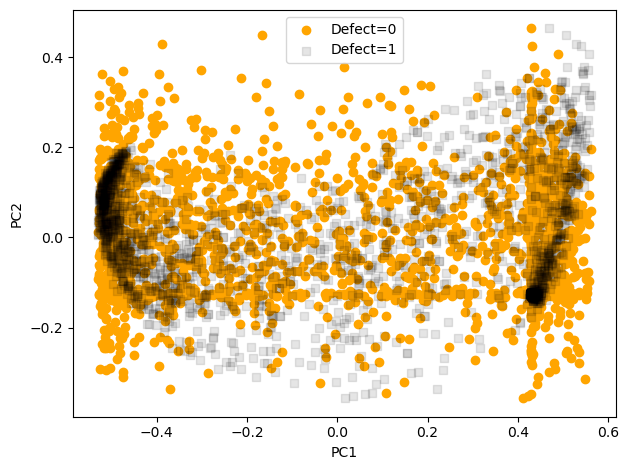

In [92]:
plt.scatter(X_train_kpca[y_train==0, 0], X_train_kpca[y_train==1, 3], c='orange', label='Defect=0', marker='o')
plt.scatter(X_train_kpca[y_train==1, 0], X_train_kpca[y_train==1, 3], c='black', label='Defect=1', marker='s', alpha=0.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_std, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

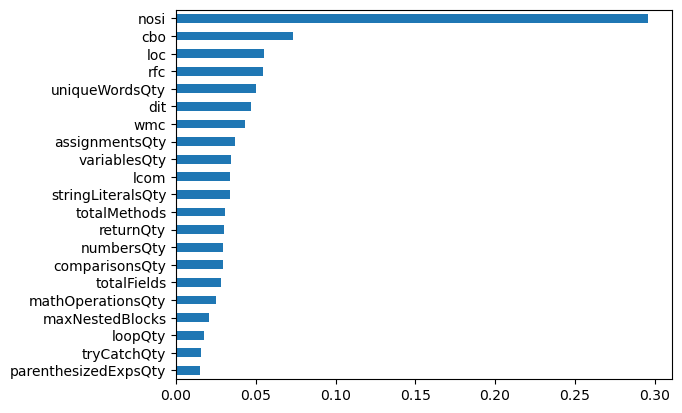

In [96]:
importances = pd.Series(rf.feature_importances_, index=dataset.columns[:-1].values)
importances.sort_values().plot(kind='barh')
plt.show()

In [97]:
RandomForestClassifier?